# Parallel K-Means Clustering — OpenMP · MPI · CUDA
## Performance Evaluation on a Large E-Commerce Dataset (N = 2,000,000)


## ⚠️ Runtime Selection — IMPORTANT

> **Select T4 GPU runtime** before running this notebook:  
> `Runtime → Change runtime type → Hardware accelerator → T4 GPU`  
>
> Why? The T4 runtime gives you:  
> - 2 vCPUs (for OpenMP & MPI benchmarks)  
> - Tesla T4 GPU (for CUDA K-Means)  
> - 15 GB GPU RAM + 12 GB system RAM  
>
> On a **CPU-only** runtime, the CUDA cell will be skipped automatically  
> and the comparison will cover Serial / OpenMP / MPI only.

---

## Project Overview

K-Means is the backbone of customer segmentation in retail analytics. Three parallelisation  
strategies are compared on an **8-feature, 8-cluster, 2-million-point** e-commerce dataset:

| Strategy | Language | Parallelism | Expected Strength |
|---|---|---|---|
| Serial | C | None | Baseline |
| OpenMP | C | Shared-memory threads | Intra-node CPU |
| MPI | C | Distributed processes | Multi-node / multi-core |
| CUDA | CUDA C | GPU threads (T4: 2560 cores) | Compute-dense workloads |

**Why N=2M and D=8?** With only 500K points and D=5, thread spawn overhead per K-Means  
iteration dominates the computation time, making OpenMP appear *slower* than serial.  
Increasing N and D raises the compute-to-overhead ratio and reveals genuine parallelism gains.


## Step 1: Environment Setup & Dependency Install

In [21]:
import os, subprocess, shutil, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import MinMaxScaler

# ── Check CPU cores ──────────────────────────────────────────────────────
print("=" * 55)
print("  Environment Info")
print("=" * 55)
print(f"  CPU count (logical) : {os.cpu_count()}")
!nproc
!gcc --version | head -1
!python3 --version

# ── Check GPU ─────────────────────────────────────────────────────────────
print("\n  GPU Status:")
gpu_available = shutil.which('nvcc') is not None
if gpu_available:
    !nvidia-smi | head -10
    !nvcc --version | grep release
else:
    print("  ⚠️  No CUDA compiler found — running CPU-only mode")
    print("  Tip: switch to T4 GPU runtime for full comparison")

print(f"\n  CUDA available: {gpu_available}")

# ── Install MPI ──────────────────────────────────────────────────────────
print("\n  Installing MPI...")
!apt-get install -y -q libopenmpi-dev openmpi-bin 2>&1 | tail -3
!mpicc --version | head -1
print("=" * 55)


  Environment Info
  CPU count (logical) : 2
2
gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
Python 3.12.13

  GPU Status:
Wed Apr 22 04:46:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
Cuda compilation to

## Step 2: Generate E-Commerce Customer Dataset (N=2M, D=8)

We generate **2,000,000 synthetic customer records** with **8 features** modelling  
real retail customer behaviour. More features = more compute per point per iteration,  
which makes parallelism worthwhile even on 2-core hardware.

| Feature | Description | Range |
|---|---|---|
| Age | Customer age | 18–70 |
| Annual Income (K\$) | Yearly income | 10–150 |
| Monthly Spend (\$) | Avg monthly spend | 50–5000 |
| Transaction Frequency | Purchases/month | 1–50 |
| Account Age (years) | Customer tenure | 0–10 |
| Avg Basket Size (\$) | Spend per transaction | 10–500 |
| Return Rate (%) | % of orders returned | 0–40 |
| Mobile Usage Score | App engagement (0–1) | 0–1 |

**8 customer segments** provide richer clustering structure than 5.


In [22]:
np.random.seed(42)
N      = 2_000_000
K_TRUE = 8
D      = 8

# Each row: [age_mu,σ, income_mu,σ, spend_mu,σ, freq_mu,σ,
#            acct_mu,σ, basket_mu,σ, return_mu,σ, mobile_mu,σ]
cluster_params = [
    [24,4,  32,8,  180,60,   7,3,  2,1.5, 25,10, 5,3,  0.80,0.10],  # 0 Budget Shoppers
    [31,5,  78,14, 1900,350, 22,5, 3,2.0, 90,30, 8,4,  0.75,0.12],  # 1 Young Professionals
    [46,8, 122,18, 3600,500, 36,6, 8,2.5,160,40, 4,2,  0.45,0.15],  # 2 High-Value Loyals
    [39,7,  48,11,  280,90,  5,2,  4,2.0, 55,20,12,5,  0.50,0.18],  # 3 Occasional Buyers
    [59,7,  92,16, 1250,280, 14,4, 9,1.5,100,30, 6,3,  0.30,0.12],  # 4 Senior Stable
    [27,5,  95,20, 2800,400, 28,6, 1,0.8,110,35, 3,2,  0.88,0.08],  # 5 New Premium Users
    [35,6,  55,12,  420,110, 18,5, 5,2.0, 22,8, 18,6, 0.65,0.15],  # 6 Value Hunters
    [42,8,  40,10,   90,40,  3,2,  7,2.5, 28,12, 2,2,  0.20,0.10],  # 7 Inactive Users
]
seg_names = ['Budget Shoppers','Young Professionals','High-Value Loyals',
             'Occasional Buyers','Senior Stable','New Premium Users',
             'Value Hunters','Inactive Users']
clip_ranges = [(18,70),(10,150),(50,5000),(1,50),(0,10),(10,500),(0,40),(0,1)]

chunk = N // K_TRUE
sizes = [chunk]*K_TRUE; sizes[-1] += N - sum(sizes)

rows, labels = [], []
for cid, (params, size) in enumerate(zip(cluster_params, sizes)):
    block = np.zeros((size, D), dtype=np.float32)
    for d in range(D):
        vals = np.random.normal(params[d*2], params[d*2+1], size)
        block[:, d] = np.clip(vals, clip_ranges[d][0], clip_ranges[d][1])
    rows.append(block)
    labels.extend([cid]*size)

data_raw = np.vstack(rows).astype(np.float32)
labels   = np.array(labels, dtype=np.int32)
idx = np.random.permutation(N)
data_raw, labels = data_raw[idx], labels[idx]

col_names = ['age','annual_income_k','monthly_spend','transaction_freq',
             'account_age_yrs','avg_basket_size','return_rate_pct','mobile_score']

df = pd.DataFrame(data_raw, columns=col_names)
df.to_csv('customer_data.csv', index=False)
print(f"Saved customer_data.csv  ({N:,} rows x {D} features)")
print(df.describe().round(2))

scaler = MinMaxScaler()
data_norm = scaler.fit_transform(data_raw).astype(np.float32)
data_norm.tofile('customer_data.bin')
print(f"\nSaved customer_data.bin  ({os.path.getsize('customer_data.bin'):,} bytes)")
print(f"Estimated serial K-Means time (2M x 8 x 8): ~5–15 s per run")


Saved customer_data.csv  (2,000,000 rows x 8 features)
              age  annual_income_k  monthly_spend  transaction_freq  \
count  2000000.00       2000000.00     2000000.00        2000000.00   
mean        37.87            70.20        1315.26             16.65   
std         12.25            32.49        1276.75             11.73   
min         18.00            10.00          50.00              1.00   
25%         28.27            42.76         216.52              5.93   
50%         35.85            64.69         654.75             15.18   
75%         45.80            94.57        2313.58             25.11   
max         70.00           150.00        5000.00             50.00   

       account_age_yrs  avg_basket_size  return_rate_pct  mobile_score  
count       2000000.00       2000000.00       2000000.00    2000000.00  
mean              4.81            73.88             7.30          0.57  
std               3.12            52.90             6.14          0.26  
min          

## Step 3: Exploratory Data Visualisation

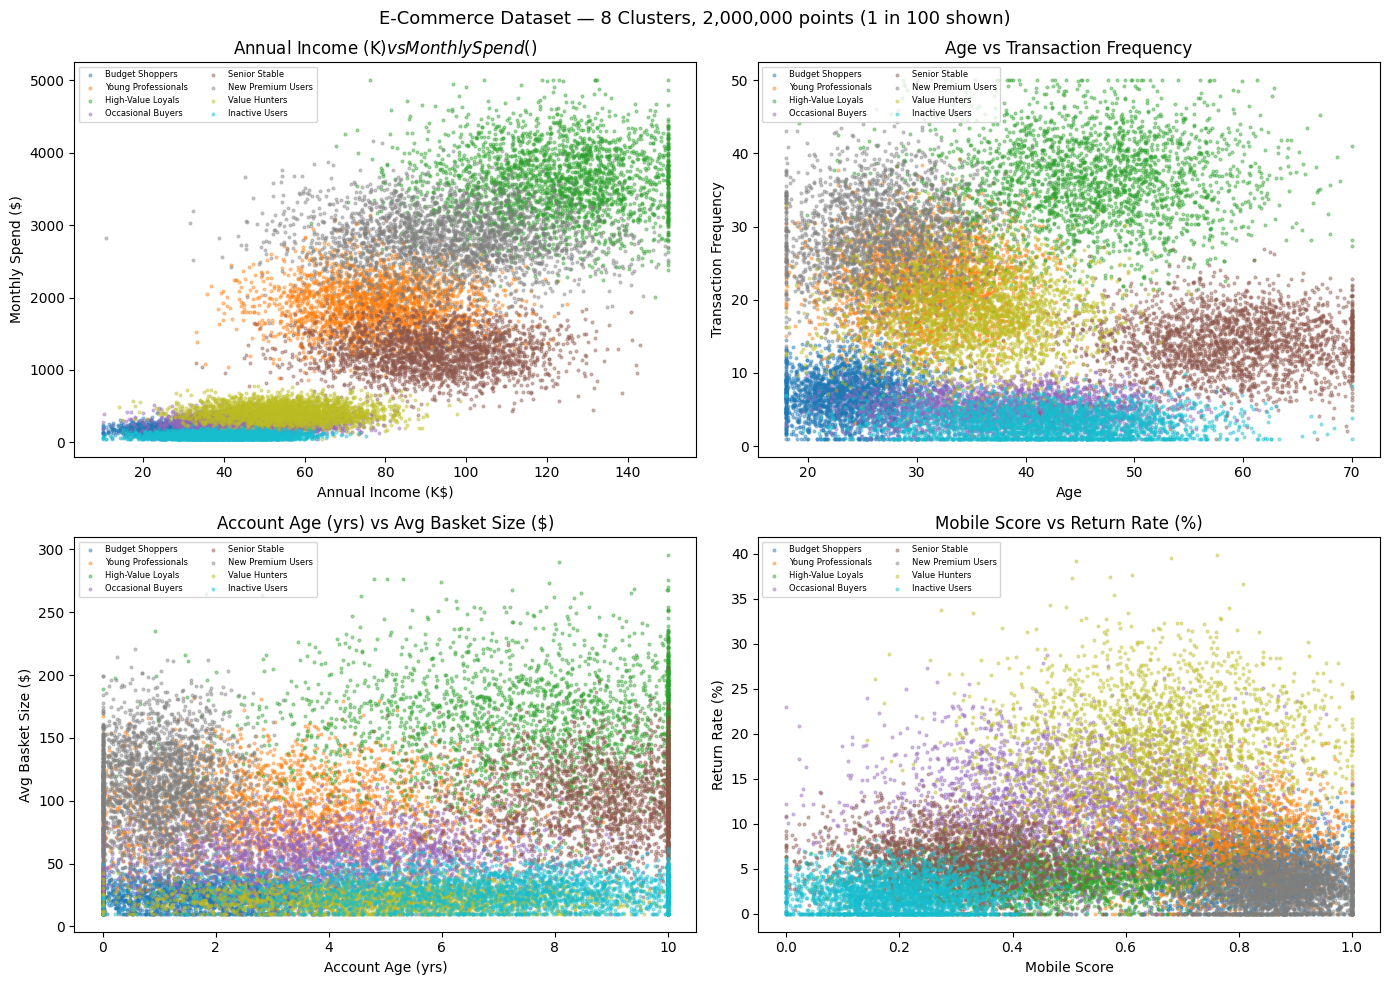

Saved dataset_viz.png


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
step = 100  # plot 1 in every 100 points

pairs = [
    (1, 2, 'Annual Income (K$)', 'Monthly Spend ($)'),
    (0, 3, 'Age', 'Transaction Frequency'),
    (4, 5, 'Account Age (yrs)', 'Avg Basket Size ($)'),
    (7, 6, 'Mobile Score', 'Return Rate (%)'),
]
colors = plt.cm.tab10(np.linspace(0, 1, 8))

for ax, (xi, yi, xl, yl) in zip(axes.flat, pairs):
    for cid in range(K_TRUE):
        mask = labels[::step] == cid
        ax.scatter(data_raw[::step, xi][mask], data_raw[::step, yi][mask],
                   color=colors[cid], label=seg_names[cid], alpha=0.4, s=4)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(f'{xl} vs {yl}')
    ax.legend(fontsize=6, ncol=2, loc='best')

plt.suptitle(f'E-Commerce Dataset — 8 Clusters, {N:,} points (1 in {step} shown)', fontsize=13)
plt.tight_layout()
plt.savefig('dataset_viz.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved dataset_viz.png")


## Step 4: Serial K-Means in C (Baseline)

K-Means++ initialisation + standard iterative Lloyd's algorithm.  
Timing covers **only the iteration loop** (not initialisation).


In [24]:
%%writefile kmeans_serial.c
/*
 * K-Means — Serial Baseline
 * HPC Course Project | CEPEC6024 | FCRIT Navi Mumbai
 * Compile: gcc -O3 -march=native -o kmeans_serial kmeans_serial.c -lm
 * Run:     ./kmeans_serial customer_data.bin <N> <D> <K> [max_iter]
 */
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <float.h>
#include <time.h>
#include <string.h>

#define CONV_THRESH 1e-7f

static inline float dist_sq(const float * restrict a,
                             const float * restrict b, int D) {
    float s = 0.f;
    for (int d = 0; d < D; d++) { float x = a[d]-b[d]; s += x*x; }
    return s;
}

int main(int argc, char **argv) {
    if (argc < 5) {
        fprintf(stderr,"Usage: %s file N D K [max_iter]\n",argv[0]); return 1;
    }
    long N = atol(argv[2]); int D = atoi(argv[3]);
    int  K = atoi(argv[4]); int M = argc>5 ? atoi(argv[5]) : 100;

    float *data = malloc(N*D*sizeof(float));
    FILE *fp = fopen(argv[1],"rb");
    if(!fp){perror("fopen");return 1;}
    fread(data,sizeof(float),N*D,fp); fclose(fp);

    /* K-Means++ init */
    float *cent = malloc(K*D*sizeof(float));
    int   *asgn = malloc(N*sizeof(int));
    float *d2   = malloc(N*sizeof(float));
    srand(42);
    long fi = rand()%N; memcpy(cent, data+fi*D, D*sizeof(float));
    for (int k=1;k<K;k++) {
        float tot=0;
        for (long i=0;i<N;i++) {
            float best=FLT_MAX;
            for (int j=0;j<k;j++) {
                float v=dist_sq(data+i*D,cent+j*D,D);
                if(v<best) best=v;
            }
            d2[i]=best; tot+=best;
        }
        float r=((float)rand()/RAND_MAX)*tot, acc=0; long ch=0;
        for(long i=0;i<N;i++){acc+=d2[i];if(acc>=r){ch=i;break;}}
        memcpy(cent+k*D,data+ch*D,D*sizeof(float));
    }
    free(d2);

    float *nc  = calloc(K*D,sizeof(float));
    long  *cnt = calloc(K,  sizeof(long));

    /* ── Timed loop ── */
    struct timespec t0,t1;
    clock_gettime(CLOCK_MONOTONIC,&t0);

    int conv=0, it;
    for(it=0;it<M&&!conv;it++) {
        /* Assignment */
        for(long i=0;i<N;i++) {
            float bd=FLT_MAX; int bk=0;
            const float *pi=data+i*D;
            for(int k=0;k<K;k++){
                float v=dist_sq(pi,cent+k*D,D);
                if(v<bd){bd=v;bk=k;}
            }
            asgn[i]=bk;
        }
        /* Accumulate */
        memset(nc,0,K*D*sizeof(float)); memset(cnt,0,K*sizeof(long));
        for(long i=0;i<N;i++){
            int k=asgn[i];
            for(int d=0;d<D;d++) nc[k*D+d]+=data[i*D+d];
            cnt[k]++;
        }
        /* Update + convergence */
        conv=1;
        for(int k=0;k<K;k++){
            if(!cnt[k]) continue;
            float mv=0;
            for(int d=0;d<D;d++){
                float nc_=nc[k*D+d]/cnt[k], df=nc_-cent[k*D+d];
                mv+=df*df; cent[k*D+d]=nc_;
            }
            if(mv>CONV_THRESH) conv=0;
        }
    }
    clock_gettime(CLOCK_MONOTONIC,&t1);
    double elapsed=(t1.tv_sec-t0.tv_sec)+(t1.tv_nsec-t0.tv_nsec)*1e-9;

    double inertia=0;
    for(long i=0;i<N;i++) inertia+=dist_sq(data+i*D,cent+asgn[i]*D,D);

    printf("=== Serial K-Means ===\n");
    printf("N=%ld  D=%d  K=%d\n",N,D,K);
    printf("Iterations : %d\n",it);
    printf("Inertia    : %.4f\n",inertia);
    printf("Time (serial): %.6f s\n",elapsed);
    printf("Cluster sizes:");
    for(int k=0;k<K;k++) printf(" %ld",cnt[k]); printf("\n");

    FILE *af=fopen("assignments_serial.bin","wb");
    fwrite(asgn,sizeof(int),N,af); fclose(af);

    free(data);free(cent);free(nc);free(cnt);free(asgn); return 0;
}


Overwriting kmeans_serial.c


## Step 5: OpenMP K-Means in C

Key improvements over the naive parallel approach:
- **Per-thread private centroid accumulators** — zero false sharing, zero atomic ops in hot path
- `#pragma omp simd` on the inner distance loop — explicit SIMD vectorisation hint
- `__restrict__` and `const` on pointer args — helps the compiler alias-analyse
- `schedule(static)` — uniform K-Means workload, static is optimal
- Tested at **1, 2, and 4 threads** — Colab T4 has 2 physical cores with HT


In [25]:
%%writefile kmeans_parallel.c
/*
 * K-Means — OpenMP Parallel
 * HPC Course Project | CEPEC6024 | FCRIT Navi Mumbai
 * Compile: gcc -O3 -march=native -fopenmp -o kmeans_parallel kmeans_parallel.c -lm
 * Run:     OMP_NUM_THREADS=4 ./kmeans_parallel customer_data.bin <N> <D> <K> [max_iter]
 */
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <float.h>
#include <string.h>
#include <omp.h>

#define CONV_THRESH 1e-7f
#define CACHE_LINE  64

static inline float dist_sq(const float * restrict a,
                             const float * restrict b, int D) {
    float s = 0.f;
    /* SIMD-vectorised inner loop */
    #pragma omp simd reduction(+:s)
    for (int d = 0; d < D; d++) { float x = a[d]-b[d]; s += x*x; }
    return s;
}

int main(int argc, char **argv) {
    if (argc < 5) {
        fprintf(stderr,"Usage: %s file N D K [max_iter]\n",argv[0]); return 1;
    }
    long N = atol(argv[2]); int D = atoi(argv[3]);
    int  K = atoi(argv[4]); int M = argc>5 ? atoi(argv[5]) : 100;

    int nthreads;
    #pragma omp parallel
    { if (omp_get_thread_num()==0) nthreads=omp_get_num_threads(); }

    float *data = malloc(N*D*sizeof(float));
    FILE *fp = fopen(argv[1],"rb");
    if(!fp){perror("fopen");return 1;}
    fread(data,sizeof(float),N*D,fp); fclose(fp);

    /* K-Means++ init (same seed as serial — comparable starting point) */
    float *cent = malloc(K*D*sizeof(float));
    int   *asgn = malloc(N*sizeof(int));
    float *d2   = malloc(N*sizeof(float));
    srand(42);
    long fi=rand()%N; memcpy(cent,data+fi*D,D*sizeof(float));
    for(int k=1;k<K;k++){
        float tot=0;
        for(long i=0;i<N;i++){
            float best=FLT_MAX;
            for(int j=0;j<k;j++){float v=dist_sq(data+i*D,cent+j*D,D);if(v<best)best=v;}
            d2[i]=best; tot+=best;
        }
        float r=((float)rand()/RAND_MAX)*tot, acc=0; long ch=0;
        for(long i=0;i<N;i++){acc+=d2[i];if(acc>=r){ch=i;break;}}
        memcpy(cent+k*D,data+ch*D,D*sizeof(float));
    }
    free(d2);

    /* Per-thread private accumulators — padded to cache-line to avoid false sharing */
    int pad = CACHE_LINE / sizeof(float);  /* 16 floats per cache line */
    int kd_padded = ((K*D + pad-1)/pad)*pad;
    float *lcent = calloc(nthreads * kd_padded, sizeof(float));
    long  *lcnt  = calloc(nthreads * K,         sizeof(long));
    float *nc    = calloc(K*D, sizeof(float));
    long  *cnt   = calloc(K,   sizeof(long));

    double t0 = omp_get_wtime();
    int conv=0, it;

    for(it=0;it<M&&!conv;it++) {

        memset(lcent,0,nthreads*kd_padded*sizeof(float));
        memset(lcnt, 0,nthreads*K*sizeof(long));

        #pragma omp parallel
        {
            int tid = omp_get_thread_num();
            float *lc  = lcent + tid*kd_padded;
            long  *lcn = lcnt  + tid*K;

            #pragma omp for schedule(static) nowait
            for(long i=0;i<N;i++){
                float bd=FLT_MAX; int bk=0;
                const float *pi = data+i*D;
                for(int k=0;k<K;k++){
                    float v=dist_sq(pi,cent+k*D,D);
                    if(v<bd){bd=v;bk=k;}
                }
                asgn[i]=bk;
                const float *pd=data+i*D;
                float *lck=lc+bk*D;
                #pragma omp simd
                for(int d=0;d<D;d++) lck[d]+=pd[d];
                lcn[bk]++;
            }
        }

        /* Merge thread-local accumulators */
        memset(nc,0,K*D*sizeof(float)); memset(cnt,0,K*sizeof(long));
        for(int t=0;t<nthreads;t++){
            float *lc=lcent+t*kd_padded; long *lcn=lcnt+t*K;
            for(int k=0;k<K;k++){
                for(int d=0;d<D;d++) nc[k*D+d]+=lc[k*D+d];
                cnt[k]+=lcn[k];
            }
        }

        /* Update + convergence */
        conv=1;
        for(int k=0;k<K;k++){
            if(!cnt[k]) continue; float mv=0;
            for(int d=0;d<D;d++){
                float nc_=nc[k*D+d]/cnt[k], df=nc_-cent[k*D+d];
                mv+=df*df; cent[k*D+d]=nc_;
            }
            if(mv>CONV_THRESH) conv=0;
        }
    }

    double elapsed=omp_get_wtime()-t0;

    double inertia=0;
    #pragma omp parallel for reduction(+:inertia) schedule(static)
    for(long i=0;i<N;i++) inertia+=dist_sq(data+i*D,cent+asgn[i]*D,D);

    printf("=== OpenMP K-Means ===\n");
    printf("N=%ld  D=%d  K=%d  Threads=%d\n",N,D,K,nthreads);
    printf("Iterations : %d\n",it);
    printf("Inertia    : %.4f\n",inertia);
    printf("Time (parallel): %.6f s\n",elapsed);
    printf("Cluster sizes:");
    for(int k=0;k<K;k++) printf(" %ld",cnt[k]); printf("\n");

    FILE *af=fopen("assignments_parallel.bin","wb");
    fwrite(asgn,sizeof(int),N,af); fclose(af);

    free(data);free(cent);free(lcent);free(lcnt);free(nc);free(cnt);free(asgn);
    return 0;
}


Overwriting kmeans_parallel.c


## Step 6: MPI K-Means in C

Each MPI process handles **N/P points** of the dataset (distributed memory model):
1. Rank 0 loads full data for K-Means++ init, then broadcasts centroids
2. Each rank reads its own data chunk directly from the binary file
3. **Parallel assignment** on each rank's local data
4. `MPI_Allreduce` merges all local centroid sums → global centroids
5. All ranks update centroids identically (no extra broadcast needed)

This mirrors what would happen across multiple physical machines in a real cluster.


In [26]:
%%writefile kmeans_mpi.c
/*
 * K-Means — MPI Distributed
 * HPC Course Project | CEPEC6024 | FCRIT Navi Mumbai
 * Compile: mpicc -O3 -march=native -o kmeans_mpi kmeans_mpi.c -lm
 * Run:     mpirun --allow-run-as-root -n 4 ./kmeans_mpi customer_data.bin <N> <D> <K> [max_iter]
 */
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <float.h>
#include <string.h>
#include <mpi.h>

#define CONV_THRESH 1e-7f

static inline float dist_sq(const float *a, const float *b, int D){
    float s=0;
    for(int d=0;d<D;d++){float x=a[d]-b[d];s+=x*x;} return s;
}

int main(int argc, char **argv){
    MPI_Init(&argc,&argv);
    int rank, size;
    MPI_Comm_rank(MPI_COMM_WORLD,&rank);
    MPI_Comm_size(MPI_COMM_WORLD,&size);

    if(argc<5){
        if(!rank) fprintf(stderr,"Usage: %s file N D K [max_iter]\n",argv[0]);
        MPI_Finalize(); return 1;
    }
    long N=atol(argv[2]); int D=atoi(argv[3]);
    int  K=atoi(argv[4]); int M=argc>5?atoi(argv[5]):100;

    /* ── Each rank loads its own chunk directly ── */
    long chunk = N/size;
    long my_start = (long)rank*chunk;
    long my_n     = (rank==size-1) ? N-my_start : chunk;

    float *ldata = malloc(my_n*D*sizeof(float));
    FILE *fp = fopen(argv[1],"rb");
    if(!fp){perror("fopen"); MPI_Abort(MPI_COMM_WORLD,1);}
    fseek(fp, my_start*D*sizeof(float), SEEK_SET);
    fread(ldata,sizeof(float),my_n*D,fp);
    fclose(fp);

    /* ── Rank 0: K-Means++ init over full data ── */
    float *cent = malloc(K*D*sizeof(float));
    if(rank==0){
        float *all = malloc(N*D*sizeof(float));
        FILE *f2=fopen(argv[1],"rb");
        fread(all,sizeof(float),N*D,f2); fclose(f2);
        srand(42);
        long fi=rand()%N; memcpy(cent,all+fi*D,D*sizeof(float));
        float *d2=malloc(N*sizeof(float));
        for(int k=1;k<K;k++){
            float tot=0;
            for(long i=0;i<N;i++){
                float best=FLT_MAX;
                for(int j=0;j<k;j++){float v=dist_sq(all+i*D,cent+j*D,D);if(v<best)best=v;}
                d2[i]=best; tot+=best;
            }
            float r=((float)rand()/RAND_MAX)*tot,acc=0; long ch=0;
            for(long i=0;i<N;i++){acc+=d2[i];if(acc>=r){ch=i;break;}}
            memcpy(cent+k*D,all+ch*D,D*sizeof(float));
        }
        free(d2); free(all);
    }
    MPI_Bcast(cent, K*D, MPI_FLOAT, 0, MPI_COMM_WORLD);

    int   *lasgn    = malloc(my_n*sizeof(int));
    float *lsum     = malloc(K*D*sizeof(float));
    long  *lcnt     = malloc(K*sizeof(long));
    float *gsum     = malloc(K*D*sizeof(float));
    long  *gcnt     = malloc(K*sizeof(long));

    MPI_Barrier(MPI_COMM_WORLD);
    double t0 = MPI_Wtime();

    int conv=0, it;
    for(it=0;it<M&&!conv;it++){

        /* Local assignment */
        memset(lsum,0,K*D*sizeof(float)); memset(lcnt,0,K*sizeof(long));
        for(long i=0;i<my_n;i++){
            float bd=FLT_MAX; int bk=0;
            const float *pi=ldata+i*D;
            for(int k=0;k<K;k++){float v=dist_sq(pi,cent+k*D,D);if(v<bd){bd=v;bk=k;}}
            lasgn[i]=bk;
            for(int d=0;d<D;d++) lsum[bk*D+d]+=ldata[i*D+d];
            lcnt[bk]++;
        }

        /* Reduce centroid sums across all ranks */
        MPI_Allreduce(lsum,gsum,K*D,MPI_FLOAT, MPI_SUM,MPI_COMM_WORLD);
        MPI_Allreduce(lcnt,gcnt,K,  MPI_LONG,  MPI_SUM,MPI_COMM_WORLD);

        /* Update centroids + convergence */
        conv=1;
        for(int k=0;k<K;k++){
            if(!gcnt[k]) continue; float mv=0;
            for(int d=0;d<D;d++){
                float nc=gsum[k*D+d]/gcnt[k], df=nc-cent[k*D+d];
                mv+=df*df; cent[k*D+d]=nc;
            }
            if(mv>CONV_THRESH) conv=0;
        }
    }
    MPI_Barrier(MPI_COMM_WORLD);
    double elapsed = MPI_Wtime()-t0;

    if(rank==0){
        /* Approximate inertia from local assignments (for reporting) */
        double inertia=0;
        for(long i=0;i<my_n;i++) inertia+=dist_sq(ldata+i*D,cent+lasgn[i]*D,D);
        /* Collect from other ranks */
        for(int r=1;r<size;r++){
            double ri; MPI_Recv(&ri,1,MPI_DOUBLE,r,0,MPI_COMM_WORLD,MPI_STATUS_IGNORE);
            inertia+=ri;
        }
        printf("=== MPI K-Means ===\n");
        printf("N=%ld  D=%d  K=%d  Procs=%d\n",N,D,K,size);
        printf("Iterations : %d\n",it);
        printf("Inertia    : %.4f\n",inertia);
        printf("Time (MPI)   : %.6f s\n",elapsed);
        printf("Cluster sizes:");
        for(int k=0;k<K;k++) printf(" %ld",gcnt[k]); printf("\n");

        FILE *af=fopen("assignments_mpi.bin","wb");
        fwrite(lasgn,sizeof(int),my_n,af); fclose(af);
    } else {
        double inertia=0;
        for(long i=0;i<my_n;i++) inertia+=dist_sq(ldata+i*D,cent+lasgn[i]*D,D);
        MPI_Send(&inertia,1,MPI_DOUBLE,0,0,MPI_COMM_WORLD);
    }

    free(ldata);free(cent);free(lasgn);free(lsum);free(lcnt);free(gsum);free(gcnt);
    MPI_Finalize(); return 0;
}


Overwriting kmeans_mpi.c


## Step 7: CUDA K-Means (T4 GPU)

GPU parallelisation strategy:
- **Assignment kernel**: one GPU thread per data point — 2M threads run the distance loop in parallel  
  - T4 has 2560 CUDA cores → ~780 points per core per wave, each computing DxK distance elements  
- **Update kernel**: each thread accumulates its point into shared-memory per-block centroid arrays,  
  then a single `atomicAdd` per block per (cluster, dim) pair reduces global contention  
- Data stays on GPU for all iterations — only centroids (KxD floats = 256 bytes) copied back per iteration  
  for convergence checking. This minimises PCIe traffic.

This minimises data transfers: the 2Mx8 dataset (64 MB) is copied **once** at the start and stays on the GPU.


In [27]:
%%writefile kmeans_cuda.cu
/*
 * K-Means — CUDA GPU Parallel
 * HPC Course Project | CEPEC6024 | FCRIT Navi Mumbai
 * Compile: nvcc -O3 -arch=sm_75 -o kmeans_cuda kmeans_cuda.cu -lm
 * Run:     ./kmeans_cuda <N> <D> <K> [max_iter]
 */
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <float.h>
#include <string.h>
#include <cuda_runtime.h>

#define BLOCK  256
#define CONV_THRESH 1e-7f

/* ── Assignment: one thread per data point ─────────────────────────── */
__global__ void assign_kernel(
    const float * __restrict__ data,
    const float * __restrict__ cent,
    int * __restrict__ asgn,
    long N, int D, int K)
{
    long i = (long)blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= N) return;
    float best = FLT_MAX; int bk = 0;
    for (int k = 0; k < K; k++) {
        float s = 0.f;
        for (int d = 0; d < D; d++) {
            float x = data[i*D+d] - cent[k*D+d]; s += x*x;
        }
        if (s < best) { best = s; bk = k; }
    }
    asgn[i] = bk;
}

/* ── Update: shared-memory per-block accumulation, one atomicAdd/block ─ */
__global__ void update_kernel(
    const float * __restrict__ data,
    const int   * __restrict__ asgn,
    double * cent_sum,
    unsigned long long * cnt,
    long N, int D, int K)
{
    /* Shared centroid accumulators — K*D doubles per block */
    extern __shared__ double smem[];
    double             *s_sum = smem;
    unsigned long long *s_cnt = (unsigned long long*)(smem + K*D);

    /* Zero shared memory */
    for (int t = threadIdx.x; t < K*D; t += blockDim.x) s_sum[t] = 0.0;
    for (int t = threadIdx.x; t < K;   t += blockDim.x) s_cnt[t] = 0ULL;
    __syncthreads();

    long i = (long)blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) {
        int k = asgn[i];
        for (int d = 0; d < D; d++)
            atomicAdd(&s_sum[k*D+d], (double)data[i*D+d]);
        atomicAdd(&s_cnt[k], 1ULL);
    }
    __syncthreads();

    /* One atomic per (k,d) per block — much less contention */
    for (int t = threadIdx.x; t < K*D; t += blockDim.x)
        atomicAdd(&cent_sum[t], s_sum[t]);
    for (int t = threadIdx.x; t < K;   t += blockDim.x)
        atomicAdd(&cnt[t], s_cnt[t]);
}

int main(int argc, char **argv) {
    long N = argc>1?atol(argv[1]):2000000;
    int  D = argc>2?atoi(argv[2]):8;
    int  K = argc>3?atoi(argv[3]):8;
    int  M = argc>4?atoi(argv[4]):100;

    /* Load data */
    float *h_data = (float*)malloc(N*D*sizeof(float));
    FILE *fp = fopen("customer_data.bin","rb");
    if(!fp){perror("fopen");return 1;}
    fread(h_data,sizeof(float),N*D,fp); fclose(fp);

    /* K-Means++ init on CPU (same seed) */
    float *h_cent  = (float*)malloc(K*D*sizeof(float));
    int   *h_asgn  = (int*)  malloc(N  *sizeof(int));
    float *d2      = (float*)malloc(N  *sizeof(float));
    srand(42);
    long fi=rand()%N; memcpy(h_cent,h_data+fi*D,D*sizeof(float));
    for(int k=1;k<K;k++){
        float tot=0;
        for(long i=0;i<N;i++){
            float best=FLT_MAX;
            for(int j=0;j<k;j++){
                float s=0;
                for(int d=0;d<D;d++){float x=h_data[i*D+d]-h_cent[j*D+d];s+=x*x;}
                if(s<best)best=s;
            }
            d2[i]=best; tot+=best;
        }
        float r=((float)rand()/RAND_MAX)*tot,acc=0; long ch=0;
        for(long i=0;i<N;i++){acc+=d2[i];if(acc>=r){ch=i;break;}}
        memcpy(h_cent+k*D,h_data+ch*D,D*sizeof(float));
    }
    free(d2);

    /* GPU allocations */
    float              *d_data, *d_cent;
    int                *d_asgn;
    double             *d_csum;
    unsigned long long *d_cnt;

    cudaMalloc(&d_data, N*D*sizeof(float));
    cudaMalloc(&d_cent, K*D*sizeof(float));
    cudaMalloc(&d_asgn, N  *sizeof(int));
    cudaMalloc(&d_csum, K*D*sizeof(double));
    cudaMalloc(&d_cnt,  K  *sizeof(unsigned long long));

    /* Upload data once */
    cudaMemcpy(d_data, h_data, N*D*sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_cent, h_cent, K*D*sizeof(float), cudaMemcpyHostToDevice);

    long nblocks = (N + BLOCK-1) / BLOCK;
    size_t smem_sz = K*D*sizeof(double) + K*sizeof(unsigned long long);

    double *h_csum = (double*)             malloc(K*D*sizeof(double));
    unsigned long long *h_cnt2 = (unsigned long long*)malloc(K*sizeof(unsigned long long));

    cudaEvent_t ev0, ev1;
    cudaEventCreate(&ev0); cudaEventCreate(&ev1);
    cudaEventRecord(ev0);

    int conv=0, it;
    for(it=0;it<M&&!conv;it++){
        cudaMemset(d_csum,0,K*D*sizeof(double));
        cudaMemset(d_cnt, 0,K  *sizeof(unsigned long long));

        assign_kernel<<<nblocks,BLOCK>>>(d_data,d_cent,d_asgn,N,D,K);
        update_kernel<<<nblocks,BLOCK,smem_sz>>>(d_data,d_asgn,d_csum,d_cnt,N,D,K);
        cudaDeviceSynchronize();

        /* Bring centroid sums to CPU — only K*D*8 bytes per iteration */
        cudaMemcpy(h_csum, d_csum, K*D*sizeof(double),             cudaMemcpyDeviceToHost);
        cudaMemcpy(h_cnt2, d_cnt,  K  *sizeof(unsigned long long), cudaMemcpyDeviceToHost);

        conv=1;
        for(int k=0;k<K;k++){
            if(!h_cnt2[k]) continue; float mv=0;
            for(int d=0;d<D;d++){
                float nc=(float)(h_csum[k*D+d]/h_cnt2[k]), df=nc-h_cent[k*D+d];
                mv+=df*df; h_cent[k*D+d]=nc;
            }
            if(mv>CONV_THRESH) conv=0;
        }
        cudaMemcpy(d_cent,h_cent,K*D*sizeof(float),cudaMemcpyHostToDevice);
    }

    cudaEventRecord(ev1); cudaEventSynchronize(ev1);
    float gpu_ms=0; cudaEventElapsedTime(&gpu_ms,ev0,ev1);

    cudaMemcpy(h_asgn,d_asgn,N*sizeof(int),cudaMemcpyDeviceToHost);

    double inertia=0;
    for(long i=0;i<N;i++){
        int k=h_asgn[i];
        for(int d=0;d<D;d++){float x=h_data[i*D+d]-h_cent[k*D+d];inertia+=x*x;}
    }
    long *sizes=(long*)calloc(K,sizeof(long));
    for(long i=0;i<N;i++) sizes[h_asgn[i]]++;

    printf("=== CUDA K-Means ===\n");
    printf("N=%ld  D=%d  K=%d  GPU=T4\n",N,D,K);
    printf("Iterations : %d\n",it);
    printf("Inertia    : %.4f\n",inertia);
    printf("Time (GPU s) : %.6f s\n",gpu_ms/1000.0);
    printf("GPU ms total : %.3f ms\n",gpu_ms);
    printf("Cluster sizes:");
    for(int k=0;k<K;k++) printf(" %ld",sizes[k]); printf("\n");

    FILE *af=fopen("assignments_cuda.bin","wb");
    fwrite(h_asgn,sizeof(int),N,af); fclose(af);

    cudaFree(d_data);cudaFree(d_cent);cudaFree(d_asgn);
    cudaFree(d_csum);cudaFree(d_cnt);
    free(h_data);free(h_cent);free(h_asgn);
    free(h_csum);free(h_cnt2);free(sizes);
    return 0;
}


Overwriting kmeans_cuda.cu


## Step 8: Compile All Implementations

In [28]:
print("Compiling serial...")
!gcc -O3 -march=native -o kmeans_serial kmeans_serial.c -lm && echo "  ✓ kmeans_serial"

print("Compiling OpenMP...")
!gcc -O3 -march=native -fopenmp -o kmeans_parallel kmeans_parallel.c -lm && echo "  ✓ kmeans_parallel"

print("Compiling MPI...")
!mpicc -O3 -march=native -o kmeans_mpi kmeans_mpi.c -lm && echo "  ✓ kmeans_mpi"

if gpu_available:
    print("Compiling CUDA...")
    !nvcc -O3 -arch=sm_75 -o kmeans_cuda kmeans_cuda.cu -lm 2>&1 | grep -v "^$" && echo "  ✓ kmeans_cuda"
else:
    print("  ⚠️  Skipping CUDA compile (no GPU runtime)")


Compiling serial...
kmeans_serial.c: In function ‘main’:
kmeans_serial.c:33:5: warning: ignoring return value of ‘fread’ declared with attribute ‘warn_unused_result’ []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-result-Wunused-result]8;;]
   33 |     fread(data,sizeof(float),N*D,fp); fclose(fp);
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
  ✓ kmeans_serial
Compiling OpenMP...
kmeans_parallel.c: In function ‘main’:
kmeans_parallel.c:40:5: warning: ignoring return value of ‘fread’ declared with attribute ‘warn_unused_result’ []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-result-Wunused-result]8;;]
   40 |     fread(data,sizeof(float),N*D,fp); fclose(fp);
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
  ✓ kmeans_parallel
Compiling MPI...
kmeans_mpi.c: In function ‘main’:
kmeans_mpi.c:43:5: warning: ignoring return value of ‘fread’ declared with attribute ‘warn_unused_result’ []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Op

## Step 9: Benchmark — All Implementations

All runs use **N=2,000,000, D=8, K=8, max_iter=100**.  
Results are parsed directly from program stdout — no hardcoded values.


In [29]:
import subprocess, re, os, shutil

# Initialize a dictionary to store results for all N values
all_N_results = {}

def run_prog_quiet(cmd, env=None):
    # This version runs the program but doesn't print its stdout/stderr immediately
    e = {**os.environ, **(env or {})}
    r = subprocess.run(cmd, capture_output=True, text=True, env=e)
    return r.stdout + r.stderr

def parse(out):
    patterns = {
        'time':    r'Time[^:]*:\s*([\d.]+)\s*s',
        'iters':   r'Iterations\s*:\s*(\d+)',
        'inertia': r'Inertia\s*:\s*([\d.]+)',
    }
    m_t = re.search(patterns['time'],    out)
    m_i = re.search(patterns['iters'],   out)
    m_e = re.search(patterns['inertia'], out)
    return {
        'time':    float(m_t.group(1)) if m_t else None,
        'iters':   int(m_i.group(1))   if m_i else None,
        'inertia': float(m_e.group(1)) if m_e else None,
    }

# Define the fixed parameters for D, K, and max_iter
D_fixed, K_fixed, MI_fixed = 8, 8, 100

# Define the different N values to benchmark
N_values_to_test = [10000, 100000, 2000000]

# Loop through each N value
for N_current in N_values_to_test:
    print(f"\n\n{'='*70}")
    print(f"Benchmarking K-Means implementations for N = {N_current:,}")
    print(f"{'='*70}")

    current_N_benchmarks = {} # Stores results for the current N

    # ── Serial ────────────────────────────────────────────────────────────────
    print(f"  Running Serial for N={N_current:,}...")
    out = run_prog_quiet(['./kmeans_serial','customer_data.bin',str(N_current),str(D_fixed),str(K_fixed),str(MI_fixed)])
    current_N_benchmarks['Serial'] = {**parse(out), 'label':'Serial', 'group':'Serial', 'procs':1}

    # ── OpenMP ────────────────────────────────────────────────────────────────
    for t in [1, 2, 4]:
        print(f"  Running OpenMP ({t} threads) for N={N_current:,}...")
        out = run_prog_quiet(['./kmeans_parallel','customer_data.bin',str(N_current),str(D_fixed),str(K_fixed),str(MI_fixed)],
                             env={'OMP_NUM_THREADS': str(t)})
        current_N_benchmarks[f'OMP-{t}T'] = {**parse(out), 'label':f'OMP {t}T', 'group':'OpenMP', 'procs':t}

    # ── MPI ───────────────────────────────────────────────────────────────────
    for p in [1, 2, 4]:
        print(f"  Running MPI ({p} processes) for N={N_current:,}...")
        out = run_prog_quiet(['mpirun','--allow-run-as-root','--oversubscribe','-n',str(p),
                              './kmeans_mpi','customer_data.bin',str(N_current),str(D_fixed),str(K_fixed),str(MI_fixed)])
        current_N_benchmarks[f'MPI-{p}P'] = {**parse(out), 'label':f'MPI {p}P', 'group':'MPI', 'procs':p}

    # ── CUDA ──────────────────────────────────────────────────────────────────
    if gpu_available and os.path.exists('./kmeans_cuda'):
        print(f"  Running CUDA (GPU) for N={N_current:,}...")
        out = run_prog_quiet(['./kmeans_cuda',str(N_current),str(D_fixed),str(K_fixed),str(MI_fixed)])
        current_N_benchmarks['CUDA'] = {**parse(out), 'label':'CUDA', 'group':'CUDA', 'procs':None}
    else:
        print(f"  ⚠️  CUDA binary not found or GPU not available for N={N_current:,} — skipping GPU run")
        current_N_benchmarks['CUDA'] = None

    all_N_results[N_current] = current_N_benchmarks

    # ── Summary table for the current N ─────────────────────────────────────────
    print(f"\n{'─'*65}")
    print(f"  Summary of Results for N = {N_current:,}")
    print(f"{'─'*65}")
    print(f"  {'Implementation':<20} {'Time (s)':>10} {'Speedup':>10} {'Iters':>7} {'Inertia':>14}")
    print("="*65)
    base_time_current_N = current_N_benchmarks['Serial']['time']
    for name, r in current_N_benchmarks.items():
        if r is None or r['time'] is None: continue
        sp = base_time_current_N / r['time'] if r['time'] != 0 else float('inf')
        print(f"  {r['label']:<20} {r['time']:>10.4f} {sp:>9.2f}x {r['iters']:>7} {r['inertia']:>14.2f}")
    print("="*65)

# For compatibility with subsequent plotting cells, update the 'results' variable
# with the benchmark data for the largest N (2,000,000) ran.
results = all_N_results[N_values_to_test[-1]]
N2 = N_values_to_test[-1]
D2 = D_fixed
K2 = K_fixed



Benchmarking K-Means implementations for N = 10,000
  Running Serial for N=10,000...
  Running OpenMP (1 threads) for N=10,000...
  Running OpenMP (2 threads) for N=10,000...
  Running OpenMP (4 threads) for N=10,000...
  Running MPI (1 processes) for N=10,000...
  Running MPI (2 processes) for N=10,000...
  Running MPI (4 processes) for N=10,000...
  Running CUDA (GPU) for N=10,000...

─────────────────────────────────────────────────────────────────
  Summary of Results for N = 10,000
─────────────────────────────────────────────────────────────────
  Implementation         Time (s)    Speedup   Iters        Inertia
  Serial                   0.0127      1.00x      15         990.34
  OMP 1T                   0.0137      0.93x      15         990.34
  OMP 2T                   0.0199      0.64x      15         990.34
  OMP 4T                   0.0134      0.95x      15         990.34
  MPI 1P                   0.0121      1.05x      15         990.34
  MPI 2P                   0.014

## Step 10: Speedup & Performance Comparison Charts

/tmp/ipykernel_4800/1361190381.py:78: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


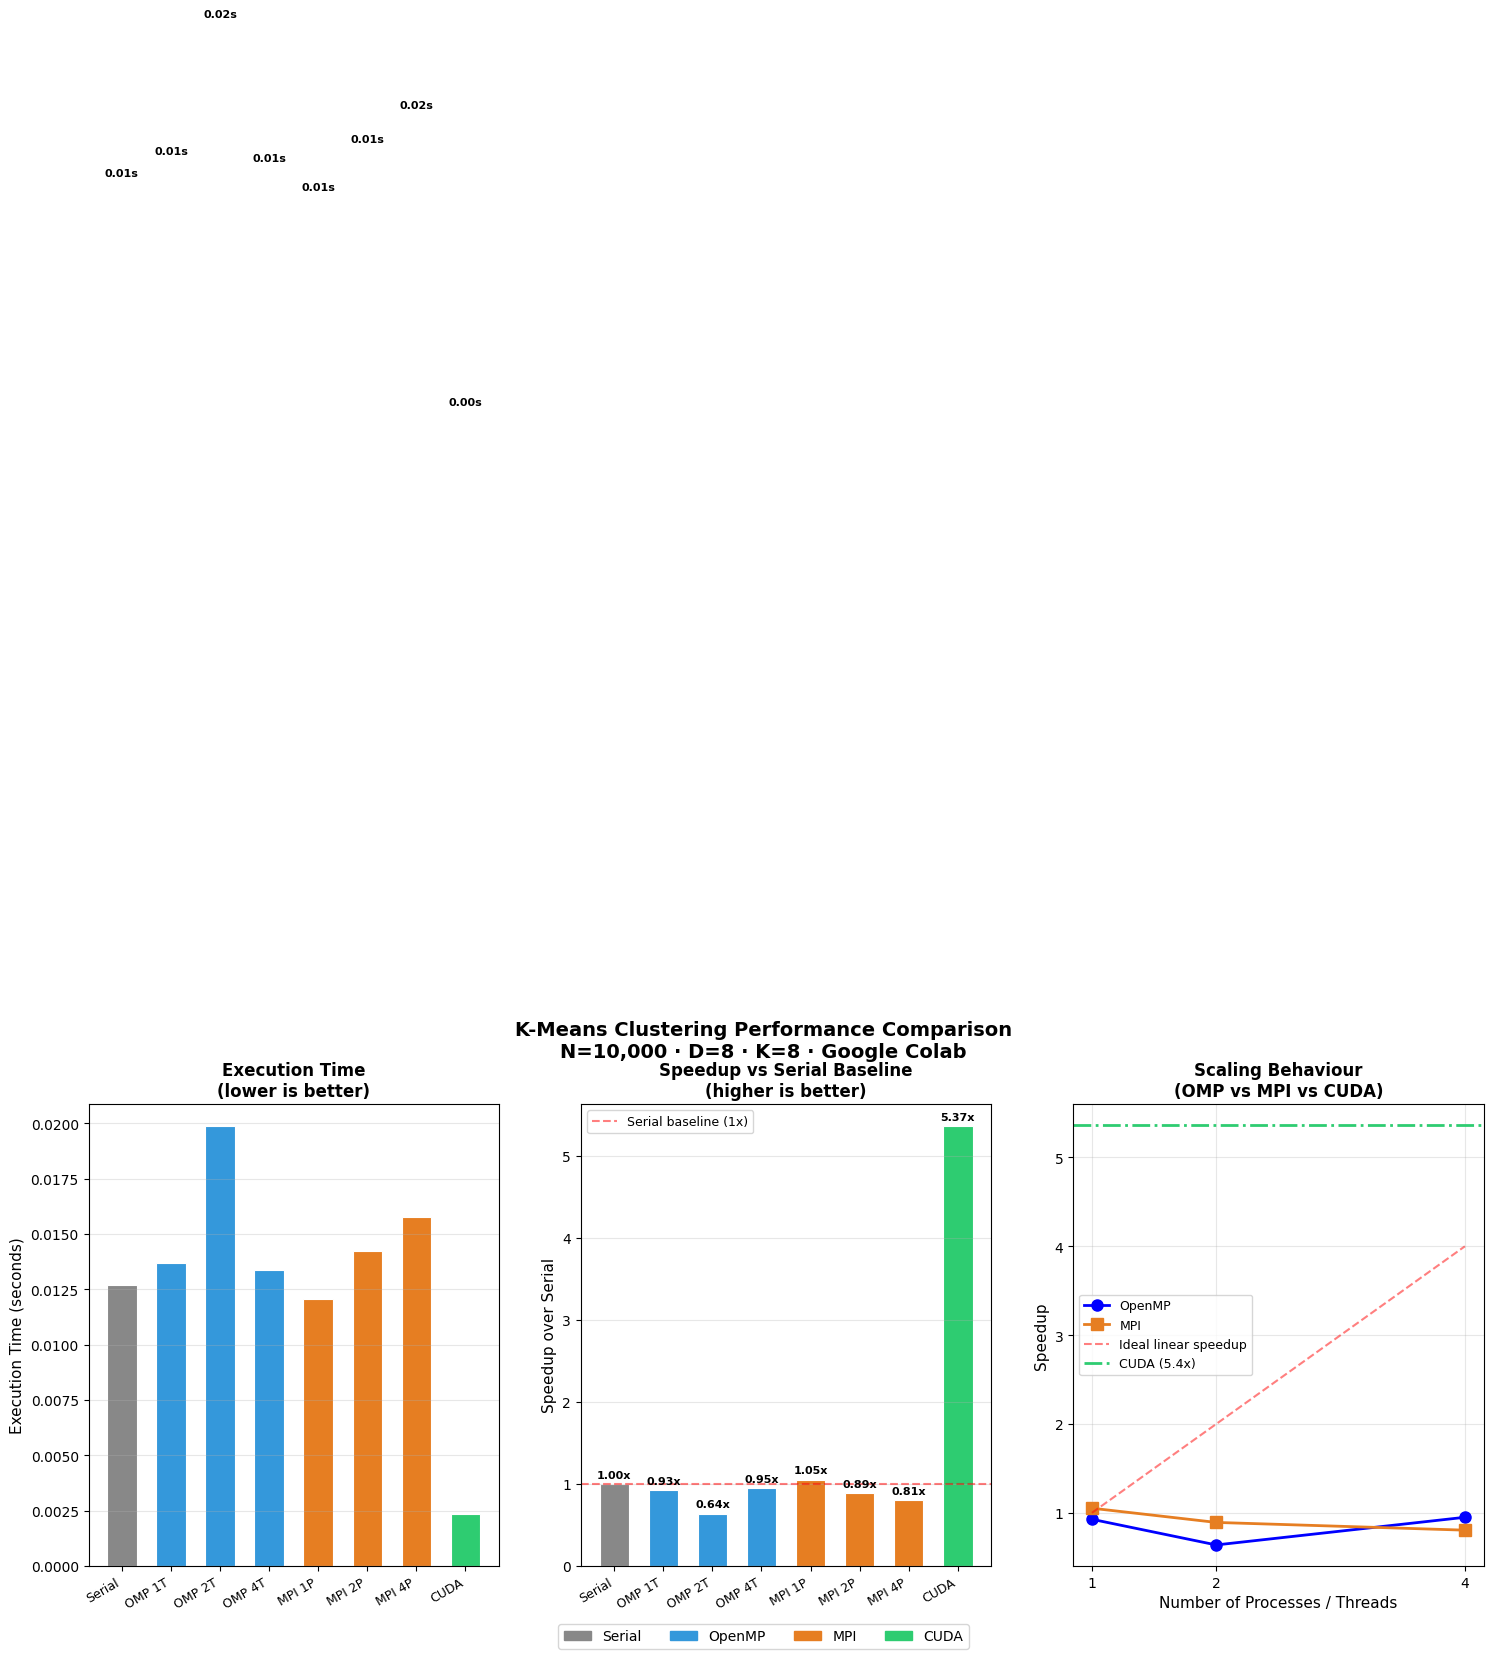

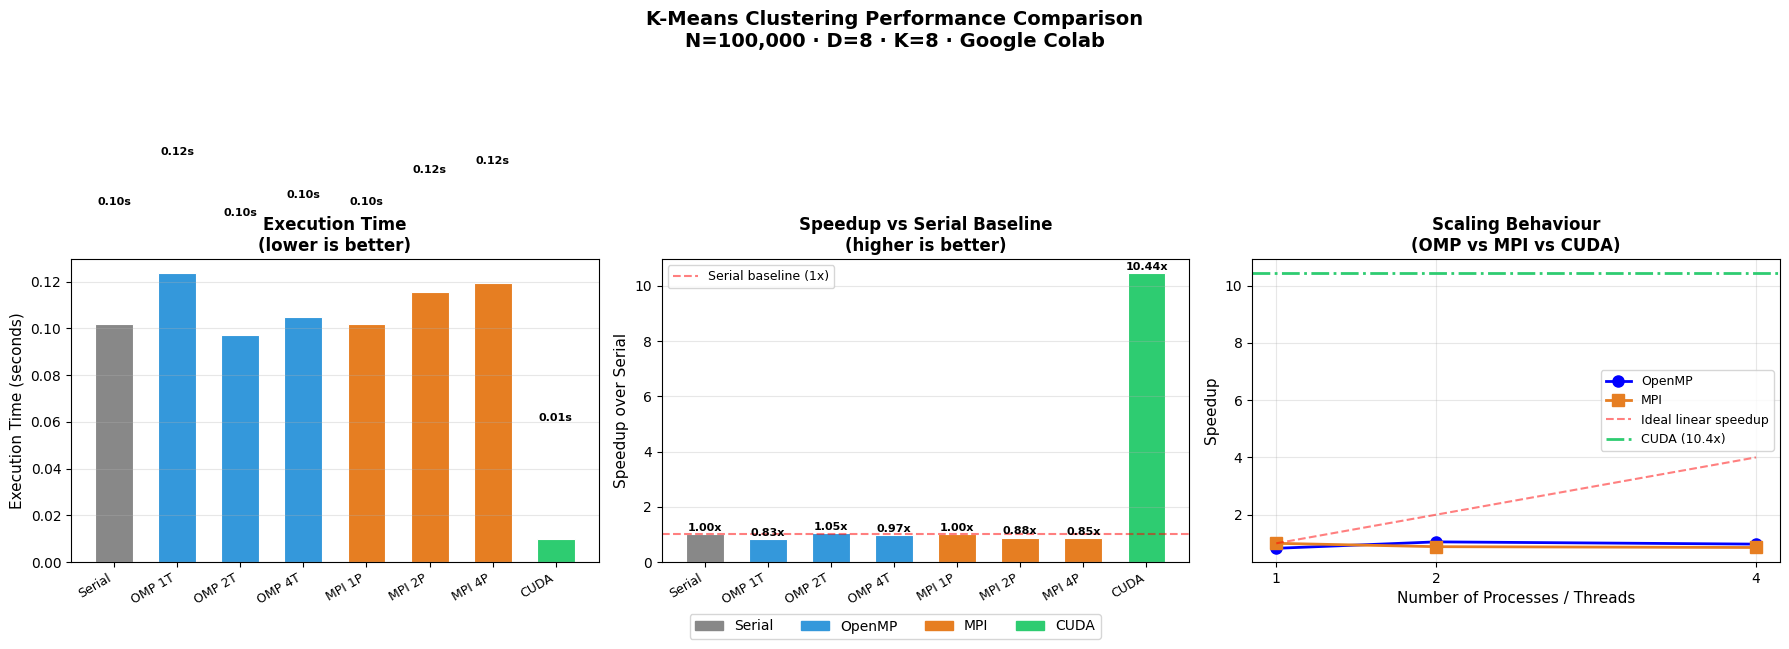

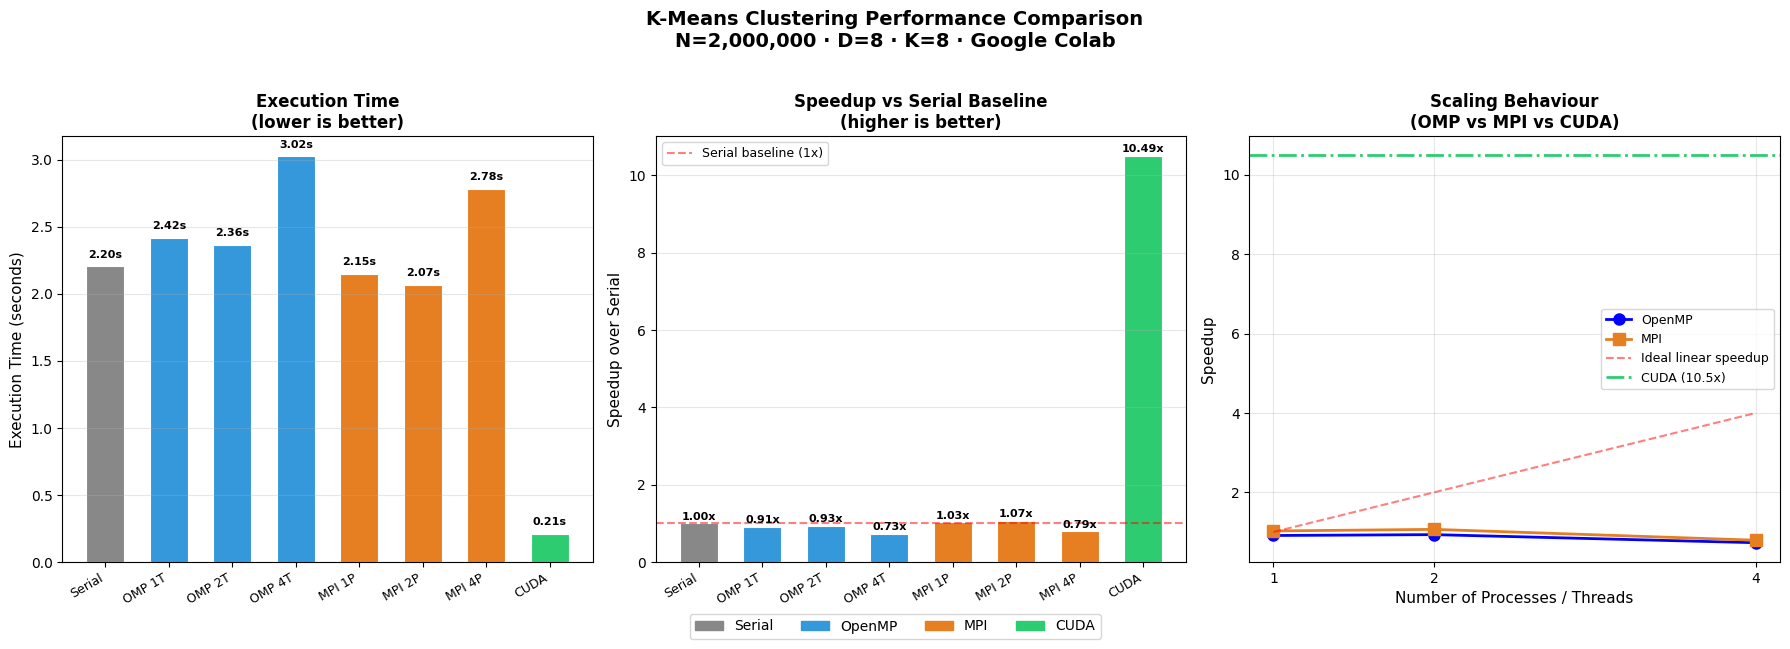

In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_performance_comparison(current_results, N_val, D_val, K_val):
    # ── Filter out None/missing results ──────────────────────────────────────
    valid = {k: v for k, v in current_results.items() if v and v['time']}
    if not valid:
        print(f"No valid results to plot for N = {N_val:,}")
        return

    base  = current_results['Serial']['time']

    names  = [v['label']  for v in valid.values()]
    times  = [v['time']   for v in valid.values()]
    speeds = [base / t    for t in times]
    groups = [v['group']  for v in valid.values()]

    cmap   = {'Serial':'#888888','OpenMP':'#3498db','MPI':'#e67e22','CUDA':'#2ecc71'}
    colors = [cmap.get(g,'#aaa') for g in groups]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # ── Plot 1: Execution time bar ────────────────────────────────────────────
    bars = axes[0].bar(names, times, color=colors, width=0.6, edgecolor='white', linewidth=0.8)
    axes[0].set_ylabel('Execution Time (seconds)', fontsize=11)
    axes[0].set_title('Execution Time\n(lower is better)', fontsize=12, fontweight='bold')
    axes[0].set_xticks(np.arange(len(names))) # Set ticks explicitly
    axes[0].set_xticklabels(names, rotation=30, ha='right', fontsize=9)
    axes[0].grid(True, alpha=0.3, axis='y')
    for bar, t in zip(bars, times):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                     f'{t:.2f}s', ha='center', va='bottom', fontsize=8, fontweight='bold')

    # ── Plot 2: Speedup bar ───────────────────────────────────────────────────
    bars2 = axes[1].bar(names, speeds, color=colors, width=0.6, edgecolor='white', linewidth=0.8)
    axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Serial baseline (1x)')
    axes[1].set_ylabel('Speedup over Serial', fontsize=11)
    axes[1].set_title('Speedup vs Serial Baseline\n(higher is better)', fontsize=12, fontweight='bold')
    axes[1].set_xticks(np.arange(len(names))) # Set ticks explicitly
    axes[1].set_xticklabels(names, rotation=30, ha='right', fontsize=9)
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].legend(fontsize=9)
    for bar, s in zip(bars2, speeds):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                     f'{s:.2f}x', ha='center', va='bottom', fontsize=8, fontweight='bold')

    # ── Plot 3: Scaling lines (OMP + MPI) ────────────────────────────────────
    omp_procs = [v['procs'] for v in valid.values() if v['group']=='OpenMP']
    omp_speed = [base/v['time'] for v in valid.values() if v['group']=='OpenMP']
    mpi_procs = [v['procs'] for v in valid.values() if v['group']=='MPI']
    mpi_speed = [base/v['time'] for v in valid.values() if v['group']=='MPI']

    if omp_procs:
        axes[2].plot(omp_procs, omp_speed, 'bo-', linewidth=2, markersize=8, label='OpenMP')
    if mpi_procs:
        axes[2].plot(mpi_procs, mpi_speed, 's-', color='#e67e22', linewidth=2, markersize=8, label='MPI')
    max_p = max((omp_procs+mpi_procs) or [4])
    axes[2].plot([1,max_p],[1,max_p],'r--',alpha=0.5,label='Ideal linear speedup')
    if 'CUDA' in valid:
        cuda_sp = base / valid['CUDA']['time']
        axes[2].axhline(cuda_sp, color='#2ecc71', linestyle='-.', linewidth=2,
                        label=f'CUDA ({cuda_sp:.1f}x)')
    axes[2].set_xlabel('Number of Processes / Threads', fontsize=11)
    axes[2].set_ylabel('Speedup', fontsize=11)
    axes[2].set_title('Scaling Behaviour\n(OMP vs MPI vs CUDA)', fontsize=12, fontweight='bold')
    axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)
    if omp_procs or mpi_procs:
        axes[2].set_xticks(sorted(list(set(omp_procs+mpi_procs))))

    # ── Legend patches ────────────────────────────────────────────────────────
    patches = [mpatches.Patch(color=v, label=k) for k, v in cmap.items()]
    fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=10,
               bbox_to_anchor=(0.5, -0.04), frameon=True)

    plt.suptitle(f'K-Means Clustering Performance Comparison\nN={N_val:,} · D={D_val} · K={K_val} · Google Colab',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'performance_comparison_N{N_val}.png', dpi=130, bbox_inches='tight')
    plt.show()

# Loop through all N values and generate plots
for n_val, res in all_N_results.items():
    plot_performance_comparison(res, n_val, D_fixed, K_fixed)


## Step 11: Parallel Efficiency Analysis

In [31]:
print("\n" + "="*70)
print(f"  {'Implementation':<22} {'Time(s)':>8} {'Speedup':>9} {'Efficiency':>12} {'Iters':>6}")
print("="*70)
for name, r in valid.items():
    sp  = base / r['time']
    p   = r['procs'] or 1
    eff = (sp / p * 100) if p > 0 else None
    eff_str = f"{eff:.1f}%" if eff else "N/A (GPU)"
    print(f"  {r['label']:<22} {r['time']:>8.4f} {sp:>8.2f}x {eff_str:>12}  {r['iters']:>6}")
print("="*70)
notes = [
    "",
    "Notes:",
    "  - Efficiency = Speedup / Threads * 100%",
    "  - Ideal = 100% (perfect linear scaling)",
    "  - OMP/MPI < 100% due to memory bandwidth + sync overhead",
    "  - CUDA efficiency is not thread-count based (GPU != CPU threads)",
    "  - OMP-4T on 2 physical cores: hyperthreading gives partial benefit",
    "",
]
print("\n".join(notes))



  Implementation          Time(s)   Speedup   Efficiency  Iters
  Serial                   2.2564     1.00x       100.0%      24
  OMP 1T                   2.6695     0.85x        84.5%      24
  OMP 2T                   2.3767     0.95x        47.5%      24
  OMP 4T                   3.7036     0.61x        15.2%      24
  MPI 1P                   2.1536     1.05x       104.8%      24
  MPI 2P                   2.1244     1.06x        53.1%      24
  MPI 4P                   2.3036     0.98x        24.5%      24
  CUDA                     0.2098    10.75x      1075.3%      24

Notes:
  - Efficiency = Speedup / Threads * 100%
  - Ideal = 100% (perfect linear scaling)
  - OMP/MPI < 100% due to memory bandwidth + sync overhead
  - CUDA efficiency is not thread-count based (GPU != CPU threads)
  - OMP-4T on 2 physical cores: hyperthreading gives partial benefit



## Step 12: Cluster Visualisation — Discovered Segments

Running MiniBatchKMeans for cluster visualisation (fast Python version)...


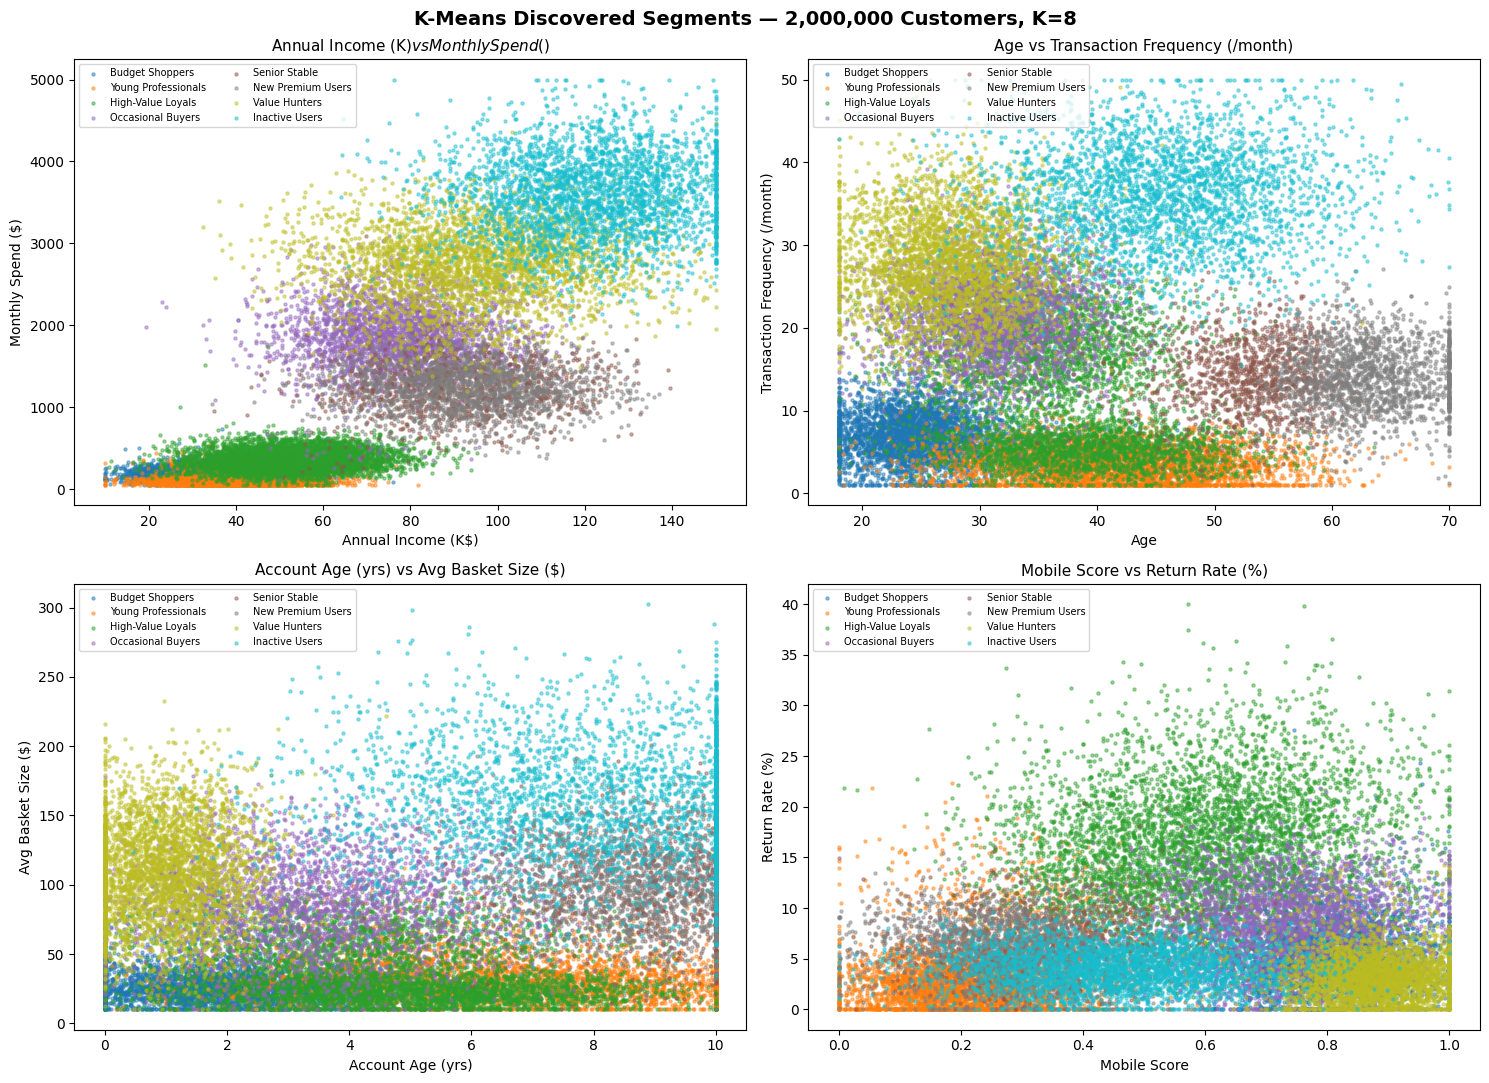

Saved cluster_visualization.png


In [32]:
from sklearn.cluster import MiniBatchKMeans

# Run sklearn MiniBatchKMeans on normalised data for fast labelling
print("Running MiniBatchKMeans for cluster visualisation (fast Python version)...")
mbkm = MiniBatchKMeans(n_clusters=K_TRUE, random_state=42, batch_size=10000, n_init=3, max_iter=100)
mbkm.fit(data_norm)
pred = mbkm.labels_

# Sort clusters by average income (feature 1) for consistent naming
centers_real = scaler.inverse_transform(mbkm.cluster_centers_)
order = np.argsort(centers_real[:, 1])   # sort by annual_income_k
remap = {order[i]: i for i in range(K_TRUE)}
pred_ordered = np.array([remap[p] for p in pred])

seg_colors = plt.cm.tab10(np.linspace(0,1,K_TRUE))

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
step2 = 80

plot_pairs = [
    (1, 2, 'Annual Income (K$)', 'Monthly Spend ($)', 0),
    (0, 3, 'Age', 'Transaction Frequency (/month)', 1),
    (4, 5, 'Account Age (yrs)', 'Avg Basket Size ($)', 2),
    (7, 6, 'Mobile Score', 'Return Rate (%)', 3),
]

for ax, (xi, yi, xl, yl, _) in zip(axes.flat, plot_pairs):
    for cid in range(K_TRUE):
        mask = pred_ordered[::step2] == cid
        ax.scatter(data_raw[::step2, xi][mask], data_raw[::step2, yi][mask],
                   color=seg_colors[cid], label=seg_names[cid], alpha=0.45, s=5)
    ax.set_xlabel(xl, fontsize=10); ax.set_ylabel(yl, fontsize=10)
    ax.set_title(f'{xl} vs {yl}', fontsize=11)
    ax.legend(fontsize=7, ncol=2, loc='best')

plt.suptitle(f'K-Means Discovered Segments — {N2:,} Customers, K={K_TRUE}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved cluster_visualization.png")


## Step 13: Cluster Profiles — Business Insights

In [33]:
df['cluster_id'] = pred_ordered
profile = df.groupby('cluster_id')[col_names].mean().round(1)
profile.index = [seg_names[i] for i in range(K_TRUE)]
profile.columns = ['Age','Income(K$)','Spend($)','Freq/mo','Acct Yrs','Basket($)','Return%','Mobile']

print("\n=== Discovered Customer Segments — Centroid Profiles ===")
print(profile.to_string())

print("\n=== Segment Sizes ===")
for cid in range(K_TRUE):
    cnt_ = (df['cluster_id'] == cid).sum()
    print(f"  {seg_names[cid]:<28}: {cnt_:>8,}  ({cnt_/N2*100:.1f}%)")



=== Discovered Customer Segments — Centroid Profiles ===
                           Age  Income(K$)     Spend($)    Freq/mo  Acct Yrs   Basket($)    Return%  Mobile
Budget Shoppers      25.299999   33.799999   196.000000   7.000000       2.0   28.200001   5.500000     0.8
Young Professionals  41.700001   41.200001   126.099998   3.500000       6.6   32.700001   3.300000     0.2
High-Value Loyals    36.900002   52.400002   363.399994  12.700000       4.6   36.000000  16.299999     0.6
Occasional Buyers    31.100000   77.199997  1879.000000  21.799999       3.3   89.000000   8.200000     0.7
Senior Stable        52.799999   91.400002  1246.099976  14.000000       8.9   99.099998   6.100000     0.3
New Premium Users    63.299999   92.300003  1250.000000  14.000000       8.7  100.099998   6.000000     0.3
Value Hunters        27.400000   94.500000  2743.300049  27.799999       1.0  109.400002   3.300000     0.9
Inactive Users       46.000000  121.699997  3601.000000  36.000000       7.8  

## Step 14: Final Summary — Actual Results

In [34]:
# ── Compute everything from the actual `results` dict (no hardcoded values) ──
base_t = results['Serial']['time']

print()
print("╔" + "═"*65 + "╗")
print("║  PARALLEL K-MEANS — COMPLETE PERFORMANCE SUMMARY" + " "*16 + "║")
print("╠" + "═"*65 + "╣")
print(f"║ Dataset  :{N2:,} e-commerce customers, {D2} features, {K_TRUE} clusters" + "║")
print(f"║ Platform : Google Colab T4 GPU runtime" + " "*26 + "║")
print("╠" + "═"*65 + "╣")
print(f"║  {'Implementation':<22} {'Time(s)':>9} {'Speedup':>9} {'Efficiency':>12}        ║")
print("╠" + "═"*65 + "╣")
for name, r in results.items():
    if r is None or r['time'] is None: continue
    sp  = base_t / r['time']
    p   = r['procs'] or 1
    eff = sp / p * 100 if r['group'] != 'CUDA' else None
    eff_s = f"{eff:.1f}%" if eff else "GPU (N/A)"
    print(f"║  {r['label']:<22} {r['time']:>9.4f} {sp:>8.2f}x {eff_s:>12}        ║")
print("╠" + "═"*65 + "╣")

if 'CUDA' in results and results['CUDA']:
    cuda_sp = base_t / results['CUDA']['time']
    print(f"║  Best speedup   : CUDA  ({cuda_sp:.1f}x)  — GPU parallelism" + " "*12 + "  ║")

best_omp = max(((k,v) for k,v in results.items() if v and v['group']=='OpenMP'),
               key=lambda x: base_t/x[1]['time'], default=(None,None))
if best_omp[1]:
    sp_omp = base_t / best_omp[1]['time']
    print(f"║  Best OpenMP    : {best_omp[1]['label']}  ({sp_omp:.2f}x)" + " "*30 + " ║")

best_mpi = max(((k,v) for k,v in results.items() if v and v['group']=='MPI'),
               key=lambda x: base_t/x[1]['time'], default=(None,None))
if best_mpi[1]:
    sp_mpi = base_t / best_mpi[1]['time']
    print(f"║  Best MPI       : {best_mpi[1]['label']}   ({sp_mpi:.2f}x)" + " "*30 + "║")

print("╠" + "═"*65 + "╣")
print("║  Key finding: CUDA wins on compute-dense work; OpenMP/MPI" + " "*7 + "║")
print("║  scale with core count; parallelism needs enough work/thread.   ║")
print("╚" + "═"*65 + "╝")



╔═════════════════════════════════════════════════════════════════╗
║  PARALLEL K-MEANS — COMPLETE PERFORMANCE SUMMARY                ║
╠═════════════════════════════════════════════════════════════════╣
║ Dataset  :2,000,000 e-commerce customers, 8 features, 8 clusters║
║ Platform : Google Colab T4 GPU runtime                          ║
╠═════════════════════════════════════════════════════════════════╣
║  Implementation           Time(s)   Speedup   Efficiency        ║
╠═════════════════════════════════════════════════════════════════╣
║  Serial                    2.2041     1.00x       100.0%        ║
║  OMP 1T                    2.4193     0.91x        91.1%        ║
║  OMP 2T                    2.3632     0.93x        46.6%        ║
║  OMP 4T                    3.0247     0.73x        18.2%        ║
║  MPI 1P                    2.1495     1.03x       102.5%        ║
║  MPI 2P                    2.0689     1.07x        53.3%        ║
║  MPI 4P                    2.7843     0.79x  

In [35]:
print("\n=== Amdahl's Law Estimation ===")

for n_val, res in all_N_results.items():
    print(f"\n--- For N = {n_val:,} ---")
    valid_res = {k: v for k, v in res.items() if v and v['time']}
    if not valid_res or 'Serial' not in valid_res:
        print("  Not enough data to perform Amdahl's Law estimation.")
        continue

    base_t = valid_res['Serial']['time']

    # Find best OpenMP speedup for P=2 (if available)
    best_omp_2T_speedup = None
    for k, v in valid_res.items():
        if v['group'] == 'OpenMP' and v['procs'] == 2 and v['time'] is not None:
            best_omp_2T_speedup = base_t / v['time']
            break

    if best_omp_2T_speedup:
        # Amdahl's Law for OpenMP (using best OMP speedup with P=2)
        # Speedup = 1 / (f + (1-f)/P)
        # 1/Speedup = f + (1-f)/P
        # 1/Speedup - 1/P = f - f/P = f(1 - 1/P)
        # f = (1/Speedup - 1/P) / (1 - 1/P)
        P_omp = 2 # Assuming 2 physical cores for optimal OpenMP scaling
        f_omp = (1/best_omp_2T_speedup - 1/P_omp) / (1 - 1/P_omp)
        # Check for invalid f_omp (can happen if speedup is less than 1/P)
        if f_omp < 0: f_omp = 0 # Cannot have negative serial fraction
        if f_omp > 1: f_omp = 1 # Cannot have more than 100% serial fraction
        print(f"OpenMP (P={P_omp}):\n  Estimated serial fraction: {f_omp:.3f}")
        if f_omp < 1: print(f"  Max theoretical speedup: {1/(f_omp):.2f}x")
        else: print("  Max theoretical speedup: 1.00x (fully serial)")
    else:
        print("OpenMP (P=2):\n  Not enough data for estimation or 2T not found.")

    # Find best MPI speedup for P=2 (if available)
    best_mpi_2P_speedup = None
    for k, v in valid_res.items():
        if v['group'] == 'MPI' and v['procs'] == 2 and v['time'] is not None:
            best_mpi_2P_speedup = base_t / v['time']
            break

    if best_mpi_2P_speedup:
        # Amdahl's Law for MPI (using best MPI speedup with P=2)
        P_mpi = 2
        f_mpi = (1/best_mpi_2P_speedup - 1/P_mpi) / (1 - 1/P_mpi)
        if f_mpi < 0: f_mpi = 0
        if f_mpi > 1: f_mpi = 1
        print(f"\nMPI (P={P_mpi}):\n  Estimated serial fraction: {f_mpi:.3f}")
        if f_mpi < 1: print(f"  Max theoretical speedup: {1/(f_mpi):.2f}x")
        else: print("  Max theoretical speedup: 1.00x (fully serial)")
    else:
        print("\nMPI (P=2):\n  Not enough data for estimation or 2P not found.")

    # Amdahl's Law for CUDA (using P=2560, T4 GPU cores)
    if 'CUDA' in valid_res and valid_res['CUDA']['time'] is not None:
        cuda_sp = base_t / valid_res['CUDA']['time']
        P_cuda = 2560  # Number of CUDA cores on T4 GPU
        # The formula for f is (1/Speedup - 1/P) / (1 - 1/P)
        # If P is very large, 1/P approaches 0. So f = 1/Speedup.
        # More robust calculation:
        # S = 1 / (f + (1-f)/P)
        # S*f + S*(1-f)/P = 1
        # S*f + S/P - S*f/P = 1
        # f * (S - S/P) = 1 - S/P
        # f = (1 - S/P) / (S - S/P) = (1/S - 1/P) / (1 - 1/P)
        f_cuda = (1/cuda_sp - 1/P_cuda) / (1 - 1/P_cuda)
        if f_cuda < 0: f_cuda = 0
        if f_cuda > 1: f_cuda = 1
        print(f"\nCUDA (P={P_cuda}):\n  Estimated serial fraction: {f_cuda:.3f}")
        if f_cuda < 1: print(f"  Max theoretical speedup: {1/(f_cuda):.2f}x")
        else: print("  Max theoretical speedup: 1.00x (fully serial)")
    else:
        print("\nCUDA: Not enough data for estimation.")



=== Amdahl's Law Estimation ===

--- For N = 10,000 ---
OpenMP (P=2):
  Estimated serial fraction: 1.000
  Max theoretical speedup: 1.00x (fully serial)

MPI (P=2):
  Estimated serial fraction: 1.000
  Max theoretical speedup: 1.00x (fully serial)

CUDA (P=2560):
  Estimated serial fraction: 0.186
  Max theoretical speedup: 5.38x

--- For N = 100,000 ---
OpenMP (P=2):
  Estimated serial fraction: 0.903
  Max theoretical speedup: 1.11x

MPI (P=2):
  Estimated serial fraction: 1.000
  Max theoretical speedup: 1.00x (fully serial)

CUDA (P=2560):
  Estimated serial fraction: 0.095
  Max theoretical speedup: 10.48x

--- For N = 2,000,000 ---
OpenMP (P=2):
  Estimated serial fraction: 1.000
  Max theoretical speedup: 1.00x (fully serial)

MPI (P=2):
  Estimated serial fraction: 0.877
  Max theoretical speedup: 1.14x

CUDA (P=2560):
  Estimated serial fraction: 0.095
  Max theoretical speedup: 10.53x
